# 📊 Analyse du Marché de l'Emploi Data Science
Exploration et visualisation des offres collectées via Adzuna API

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Librairies chargées')

✅ Librairies chargées


## 1. Chargement des données

In [5]:
df = pd.read_csv('../data/processed/jobs_clean.csv', encoding='utf-8-sig')

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (234, 12)
Colonnes : ['source', 'title', 'company', 'location', 'salary_min', 'salary_max', 'salary_avg', 'contract', 'category', 'description', 'url', 'created_at']


,source,title,company,location,salary_min,salary_max,salary_avg,contract,category,description,url,created_at
0,Adzuna,Data Scientist,Bizzdesign,Paris,NaN,NaN,NaN,Non précisé,Emplois Informatique,Bizzdesign is looking for a highly skilled Dat...,https://www.adzuna.fr/land/ad/5591139701?se=Io...,2026-01-19
1,Adzuna,Data Scientist,Daveo,France,NaN,NaN,NaN,Non précisé,Unknown,Daveo est un cabinet de conseil spécialisé dan...,https://www.adzuna.fr/land/ad/5595259531?se=Io...,2026-01-22
2,Adzuna,Data Scientist Senior,Groupe Atlantic,La Roche-Sur-Yon,NaN,NaN,NaN,Non précisé,Unknown,"REJOIGNEZ LE GROUPE ATLANTIC ! GA SYNERGY, siè...",https://www.adzuna.fr/land/ad/5641065161?se=Io...,2026-02-22
3,Adzuna,Data Scientist F/H (Cdi),Michael Page,Nord,NaN,NaN,NaN,Non précisé,Unknown,Cet acteur européen du secteur financier et di...,https://www.adzuna.fr/land/ad/5649130176?se=Io...,2026-02-28
4,Adzuna,Data Scientist H/F (Cdi),Michael Page,1Er Arrondissement,NaN,NaN,NaN,Non précisé,Unknown,Structure de santé qui regroupe plusieurs mill...,https://www.adzuna.fr/land/ad/5641556107?se=Io...,2026-02-22


In [6]:
# Aperçu général
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   source       234 non-null    object 
 1   title        234 non-null    object 
 2   company      231 non-null    object 
 3   location     234 non-null    object 
 4   salary_min   44 non-null     float64
 5   salary_max   44 non-null     float64
 6   salary_avg   44 non-null     float64
 7   contract     234 non-null    object 
 8   category     234 non-null    object 
 9   description  234 non-null    object 
 10  url          234 non-null    object 
 11  created_at   234 non-null    object 
dtypes: float64(3), object(9)
memory usage: 22.1+ KB


In [7]:
# Valeurs manquantes
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})

,Manquants,Pourcentage (%)
salary_max,190,81.2
salary_avg,190,81.2
salary_min,190,81.2
company,3,1.3
location,0,0.0
title,0,0.0
source,0,0.0
contract,0,0.0
category,0,0.0
description,0,0.0


## 2. Statistiques descriptives

In [8]:
print('=== Statistiques générales ===')
print(f"Nombre total d'offres      : {len(df)}")
print(f"Nombre d'entreprises uniques: {df['company'].nunique()}")
print(f"Nombre de villes uniques   : {df['location'].nunique()}")
print(f"Offres avec salaire        : {df['salary_avg'].notna().sum()} ({df['salary_avg'].notna().mean()*100:.1f}%)")
print()
print('=== Salaires (€/an) ===')
print(df['salary_avg'].describe().round(0))

=== Statistiques générales ===
Nombre total d'offres      : 234
Nombre d'entreprises uniques: 171
Nombre de villes uniques   : 67
Offres avec salaire        : 44 (18.8%)

=== Salaires (€/an) ===
count        44.0
mean      51802.0
std       20489.0
min        1100.0
25%       46375.0
50%       52500.0
75%       58876.0
max      115000.0
Name: salary_avg, dtype: float64


## 3. Distribution géographique

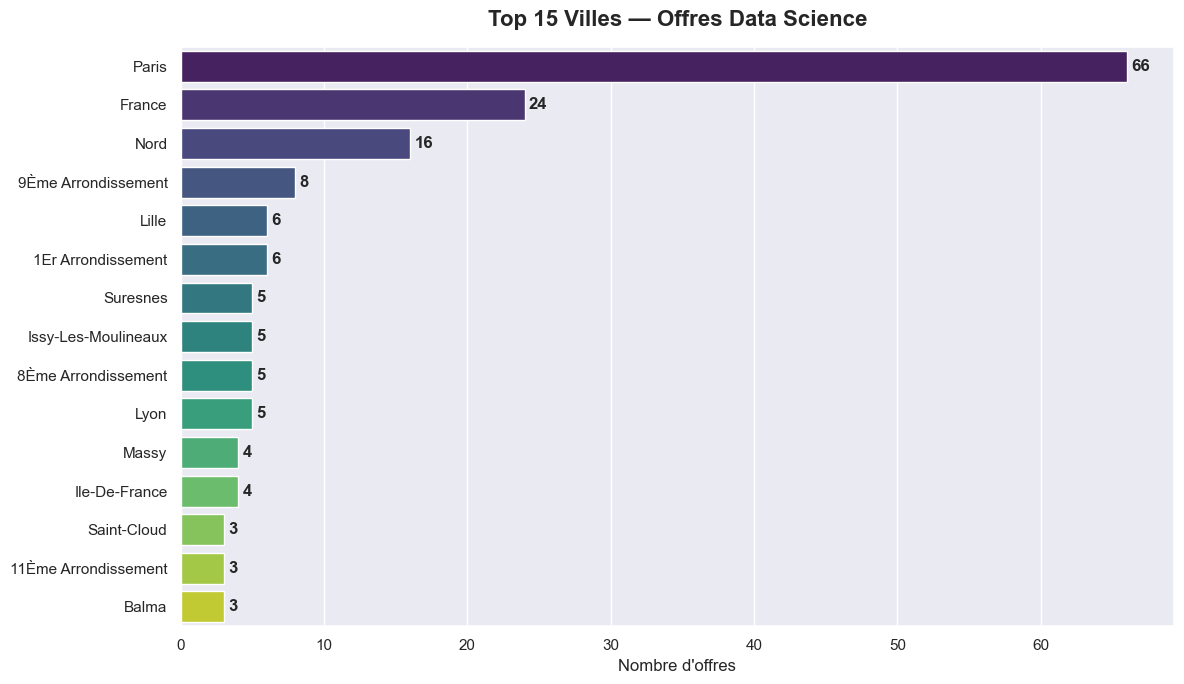

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

top_locations = df['location'].value_counts().head(15)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis', ax=ax)

ax.set_title('Top 15 Villes — Offres Data Science', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Nombre d'offres")
ax.set_ylabel('')

for i, v in enumerate(top_locations.values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/plot_locations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Types de contrats

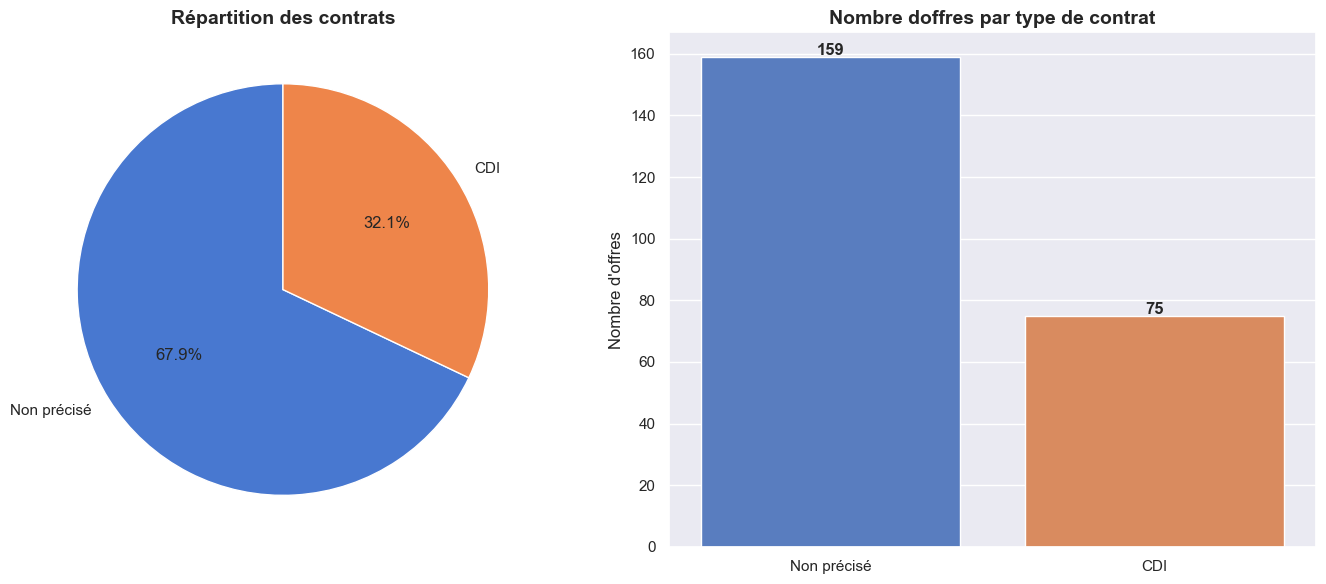

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

contract_counts = df['contract'].value_counts()

# Pie chart
axes[0].pie(contract_counts.values, labels=contract_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(contract_counts)))
axes[0].set_title('Répartition des contrats', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=contract_counts.index, y=contract_counts.values,
            palette='muted', ax=axes[1])
axes[1].set_title('Nombre doffres par type de contrat', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel("Nombre d'offres")

for i, v in enumerate(contract_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/plot_contracts.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse des salaires

Offres avec salaire : 44


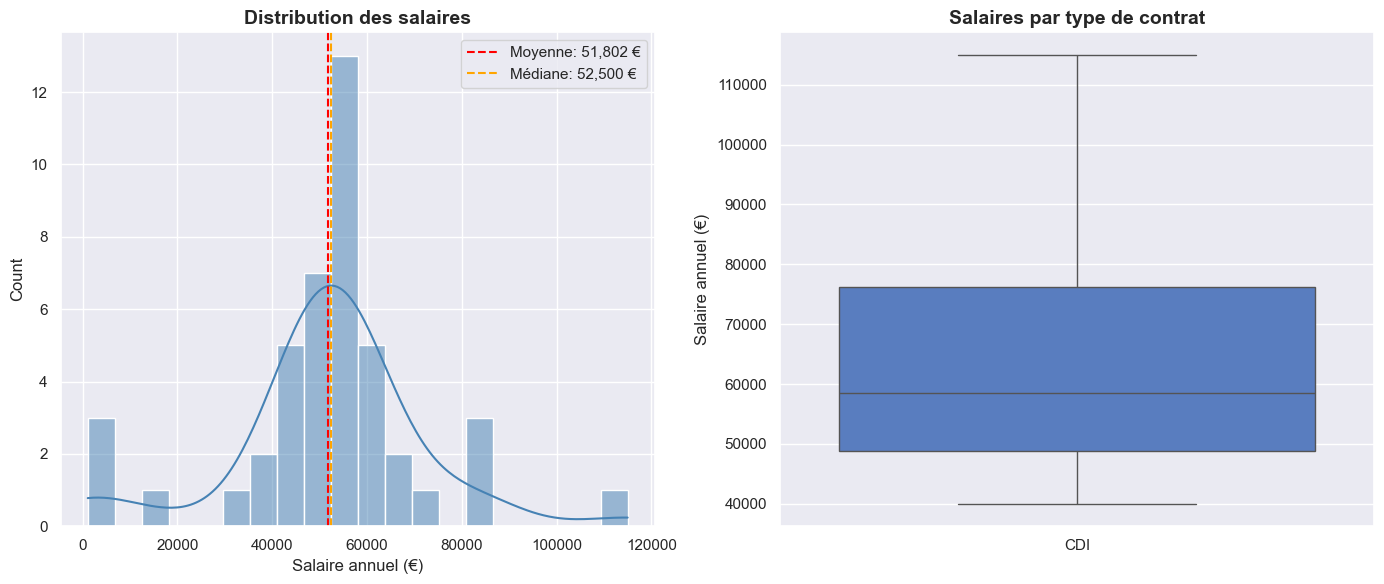

In [11]:
df_sal = df.dropna(subset=['salary_avg'])
print(f'Offres avec salaire : {len(df_sal)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution
sns.histplot(df_sal['salary_avg'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df_sal['salary_avg'].mean(), color='red', linestyle='--', label=f"Moyenne: {df_sal['salary_avg'].mean():,.0f} €")
axes[0].axvline(df_sal['salary_avg'].median(), color='orange', linestyle='--', label=f"Médiane: {df_sal['salary_avg'].median():,.0f} €")
axes[0].set_title('Distribution des salaires', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salaire annuel (€)')
axes[0].legend()

# Boxplot par contrat
df_sal_contract = df_sal[df_sal['contract'].isin(['CDI', 'CDD', 'Freelance'])]
if not df_sal_contract.empty:
    sns.boxplot(data=df_sal_contract, x='contract', y='salary_avg', palette='muted', ax=axes[1])
    axes[1].set_title('Salaires par type de contrat', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Salaire annuel (€)')
else:
    axes[1].text(0.5, 0.5, 'Pas assez de données', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('../data/processed/plot_salaires.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top compétences demandées

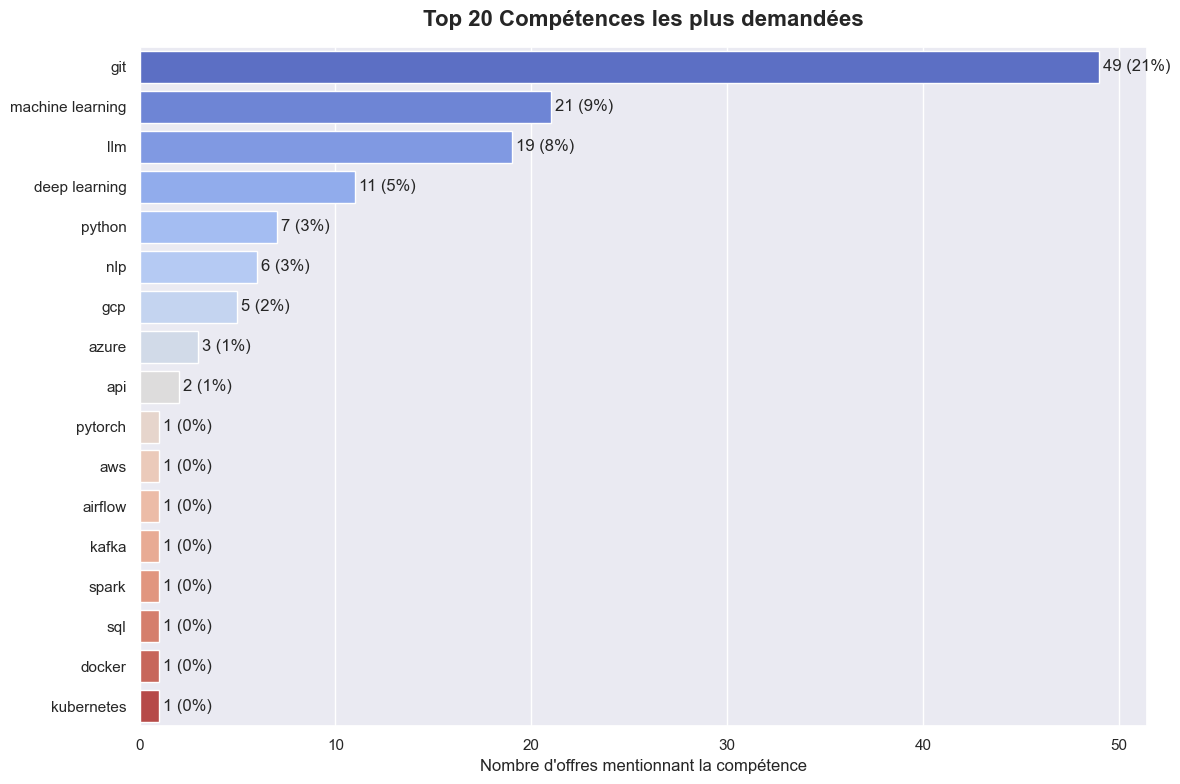

In [12]:
SKILLS_KEYWORDS = [
    'python', 'sql', 'spark', 'hadoop', 'airflow', 'kafka',
    'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy',
    'tableau', 'power bi', 'dbt', 'aws', 'gcp', 'azure',
    'docker', 'kubernetes', 'git', 'mlflow', 'nlp', 'llm',
    'machine learning', 'deep learning', 'api'
]

skill_counts = {}
for skill in SKILLS_KEYWORDS:
    count = df['description'].str.lower().str.contains(skill, na=False).sum()
    if count > 0:
        skill_counts[skill] = count

skills_df = pd.Series(skill_counts).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('coolwarm', len(skills_df))
sns.barplot(x=skills_df.values, y=skills_df.index, palette=colors, ax=ax)

ax.set_title('Top 20 Compétences les plus demandées', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Nombre d'offres mentionnant la compétence")
ax.set_ylabel('')

for i, v in enumerate(skills_df.values):
    ax.text(v + 0.2, i, f'{v} ({v/len(df)*100:.0f}%)', va='center')

plt.tight_layout()
plt.savefig('../data/processed/plot_skills.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top entreprises recruteurs

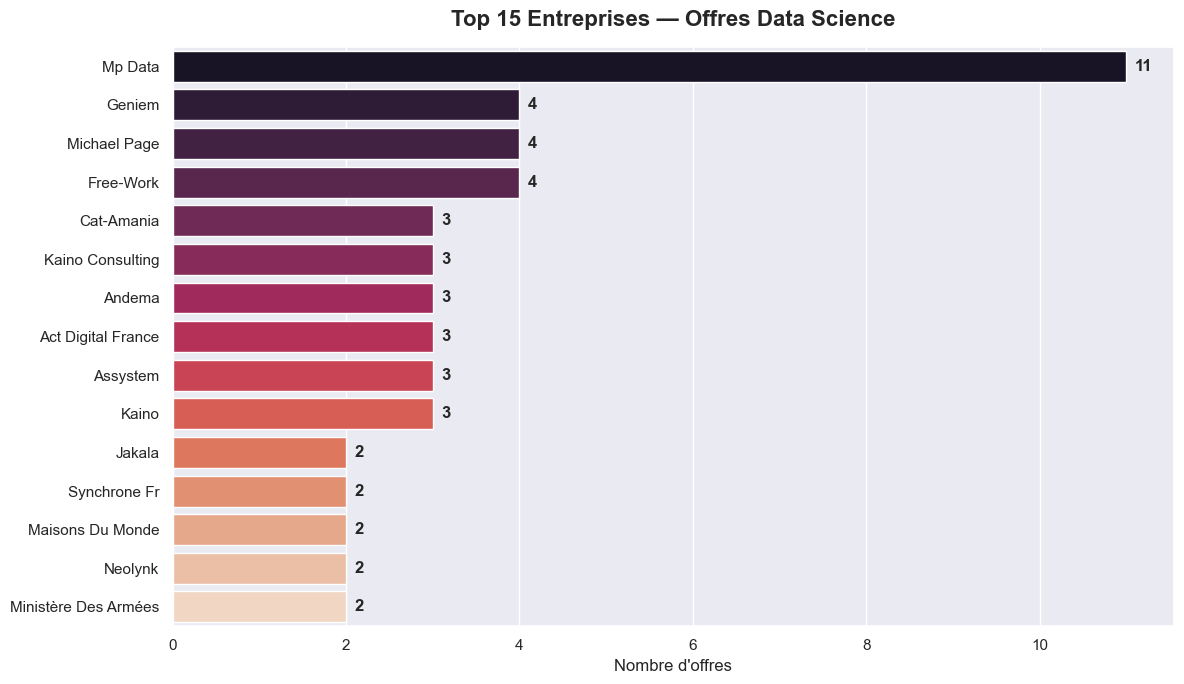

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

top_companies = df['company'].value_counts().head(15)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='rocket', ax=ax)

ax.set_title('Top 15 Entreprises — Offres Data Science', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Nombre d'offres")
ax.set_ylabel('')

for i, v in enumerate(top_companies.values):
    ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/plot_companies.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Corrélation salaire / localisation

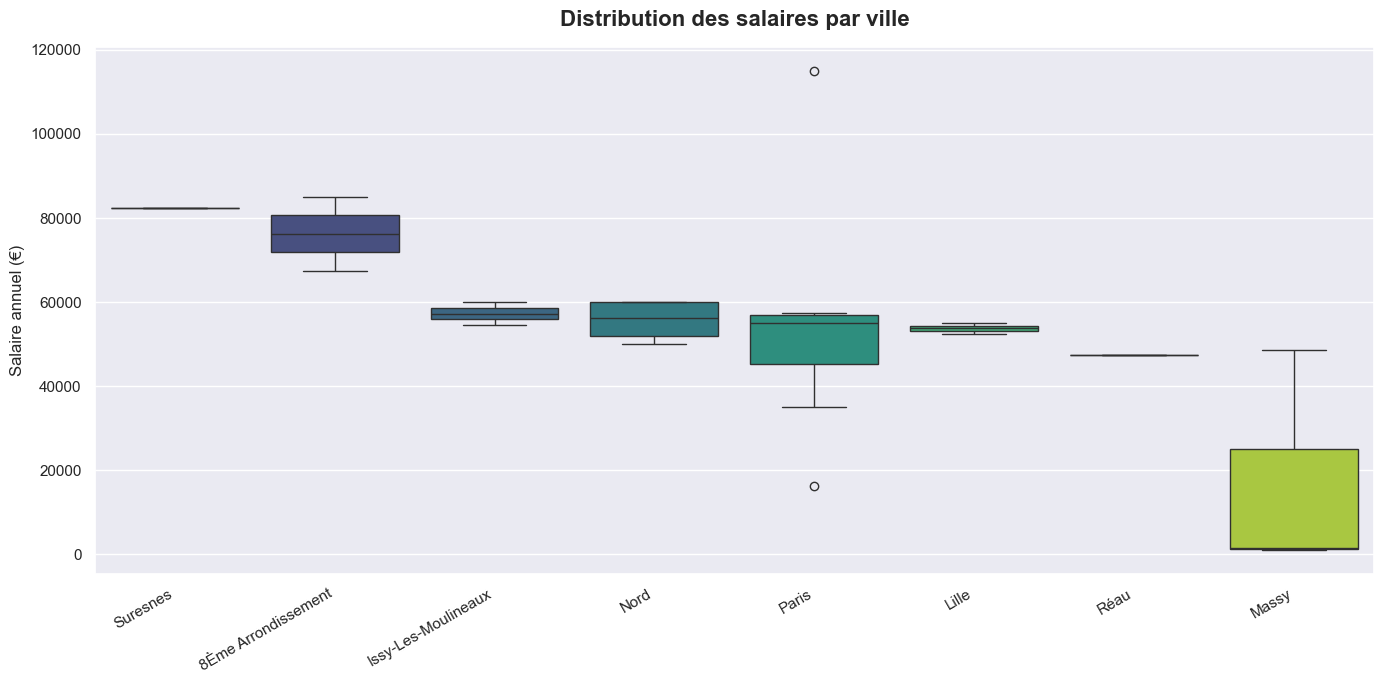

In [14]:
df_sal = df.dropna(subset=['salary_avg'])

# Villes avec au moins 2 offres avec salaire
top_cities = df_sal['location'].value_counts()
top_cities = top_cities[top_cities >= 2].head(10).index

df_cities = df_sal[df_sal['location'].isin(top_cities)]

if not df_cities.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    order = df_cities.groupby('location')['salary_avg'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_cities, x='location', y='salary_avg', order=order, palette='viridis', ax=ax)
    ax.set_title('Distribution des salaires par ville', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Salaire annuel (€)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../data/processed/plot_salary_city.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Pas assez de données salariales par ville.')

## 9. Conclusions

In [15]:
print('=' * 55)
print('  SYNTHÈSE DE L\'ANALYSE')
print('=' * 55)
print(f"  Offres analysées     : {len(df)}")
print(f"  Ville principale     : {df['location'].value_counts().index[0]}")
print(f"  Contrat dominant     : {df['contract'].value_counts().index[0]}")
print(f"  Compétence #1        : {list(skill_counts.keys())[0] if skill_counts else 'N/A'}")
if df['salary_avg'].notna().sum() > 0:
    print(f"  Salaire médian       : {df['salary_avg'].median():,.0f} €/an")
    print(f"  Salaire moyen        : {df['salary_avg'].mean():,.0f} €/an")
print('=' * 55)

  SYNTHÈSE DE L'ANALYSE
  Offres analysées     : 234
  Ville principale     : Paris
  Contrat dominant     : Non précisé
  Compétence #1        : python
  Salaire médian       : 52,500 €/an
  Salaire moyen        : 51,802 €/an
